## 🤖 Step 1: Import Required Libraries

We import all necessary libraries for data manipulation, model building, and evaluation.

In [42]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [43]:
from sklearn.preprocessing import StandardScaler

## 📂 Step 2: Load Processed Dataset

We load the cleaned dataset prepared during the EDA phase.

In [44]:
import pandas as pd
import sys
sys.path.insert(0, '../')

# Load from PostgreSQL
try:
    from src.database import get_churn_data
    df = get_churn_data()
    print("✅ Data loaded from PostgreSQL successfully!")
except Exception as e:
    print(f"⚠️ PostgreSQL connection failed: {e}")
    print("Falling back to CSV...")
    df = pd.read_csv("../data/processed_churn_data.csv")

df.head()

✅ PostgreSQL connection established
✅ PostgreSQL connection closed
✅ Data loaded from PostgreSQL successfully!


g:\Suji\Desktop\Customer-Churn-LTV-Project\notebooks\..\src\database.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, self.conn)


,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [45]:
print('df shape:', df.shape)
print(df.columns)

df shape: (7043, 21)
Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='str')


In [46]:
# Skipping: early train_test_split — features `X` are defined later in the notebook
print('Skipping duplicate train_test_split; see later cell where X and y are defined')

Skipping duplicate train_test_split; see later cell where X and y are defined


In [47]:
# Skipping: early pipeline construction — this block referenced `X` before it was defined
print('Skipping duplicate pipeline; pipeline will be built later after processing')

Skipping duplicate pipeline; pipeline will be built later after processing


In [48]:
# Skipping: early model.fit — model training occurs later in the notebook
print('Skipping duplicate model.fit; see later training cells')

Skipping duplicate model.fit; see later training cells


In [49]:
# Skipping: early model export — model is saved later after correct training
print('Skipping duplicate model export')

Skipping duplicate model export


## 📊 Step 3: Data Overview

We check the shape and structure of the dataset.

In [50]:
df.shape

(7043, 21)

In [51]:
df.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [52]:
df['churn'].value_counts()

churn
No     5174
Yes    1869
Name: count, dtype: int64

## 🎯 Step 4: Split Features and Target Variable

We separate input features (X) and target variable (y).

In [53]:
X = df.drop('churn', axis=1)
y = df['churn'].map({"Yes": 1, "No": 0})

## ✂️ Step 5: Train-Test Split

We split the dataset into training and testing sets.

In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## 🤖 Step 6: Model Building - Logistic Regression

We train a Logistic Regression model for churn prediction.

### Why Logistic Regression?
- Works well for binary classification
- Simple and interpretable
- Good baseline model

In [55]:
X_train.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges
2142,4223-BKEOR,Female,0,No,Yes,21,Yes,No,DSL,Yes,No,Yes,No,No,Yes,One year,No,Mailed check,64.85,1336.8
1623,8017-LXHFA,Female,1,No,No,23,Yes,No,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,94.75,2293.6
6074,3797-VTIDR,Male,0,Yes,No,1,No,No phone service,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,23.45,23.45
1362,9272-LSVYH,Male,0,No,No,10,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,No,Mailed check,70.15,735.5
6754,2775-SEFEE,Male,0,No,Yes,0,Yes,Yes,DSL,Yes,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,


In [56]:
# ========== FRESH DATA PIPELINE ==========

# 1. Drop unnecessary columns
df_clean = df.copy()
df_clean = df_clean.drop("customerid", axis=1)

# 2. Convert TotalCharges to numeric and handle missing values
df_clean['totalcharges'] = pd.to_numeric(df_clean['totalcharges'], errors='coerce')

# 3. Drop rows with any NaN values
df_clean = df_clean.dropna()

print(f"✅ Data shape after cleaning: {df_clean.shape}")
print(f"✅ NaN count: {df_clean.isnull().sum().sum()}")
print(f"✅ Churn distribution:\n{df_clean['churn'].value_counts()}")

✅ Data shape after cleaning: (7032, 20)
✅ NaN count: 0
✅ Churn distribution:
churn
No     5163
Yes    1869
Name: count, dtype: int64


In [57]:
# 4. Encode target variable BEFORE one-hot encoding
# Churn is already encoded (0 = No, 1 = Yes)

print("✅ Churn is already encoded.")

print(f"Class 0 (No Churn): {(df_clean['churn'] == 0).sum()}")
print(f"Class 1 (Churn): {(df_clean['churn'] == 1).sum()}")

✅ Churn is already encoded.
Class 0 (No Churn): 0
Class 1 (Churn): 0


In [58]:
print("Data Type:")
print(df_clean['churn'].dtype)

print("\nUnique Values:")
print(df_clean['churn'].unique())

print("\nFirst 5 Values:")
print(df_clean['churn'].head())

Data Type:
str

Unique Values:
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

First 5 Values:
0     No
1     No
2    Yes
3     No
4    Yes
Name: churn, dtype: str


In [60]:
# 5. Extract target variable BEFORE one-hot encoding
y = df_clean['churn']

# 6. Drop target from features
df_features = df_clean.drop('churn', axis=1)

# 7. One-hot encode categorical variables (drop_first=True to avoid multicollinearity)
df_encoded = pd.get_dummies(df_features, drop_first=True)

# 8. Split into features (X) and target (y)
X = df_encoded

print(f"✅ Features shape: {X.shape}")
print(f"✅ Target shape: {y.shape}")
print(f"✅ Target value counts:\n{y.value_counts()}")

# 9. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"✅ Train set size: {X_train.shape[0]}, Test set size: {X_test.shape[0]}")

✅ Features shape: (7032, 30)
✅ Target shape: (7032,)
✅ Target value counts:
churn
No     5163
Yes    1869
Name: count, dtype: int64
✅ Train set size: 5625, Test set size: 1407


In [61]:
# Skipping - StandardScaler will be applied next
print("✅ Data prepared, now applying StandardScaler...")

✅ Data prepared, now applying StandardScaler...


In [62]:
# 8. Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Data scaled successfully")
print(f"✅ Train set shape: {X_train_scaled.shape}")
print(f"✅ Test set shape: {X_test_scaled.shape}")

✅ Data scaled successfully
✅ Train set shape: (5625, 30)
✅ Test set shape: (1407, 30)


In [63]:
# 9. Train Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print(f"✅ Logistic Regression model trained successfully!")
print(f"✅ Model classes: {model.classes_}")

✅ Logistic Regression model trained successfully!
✅ Model classes: ['No' 'Yes']


## 🔮 Step 7: Predictions

We use the trained model to predict churn on test data.

In [64]:
y_pred = model.predict(X_test_scaled)

print(f"✅ Predictions generated!")
print(f"✅ Prediction shape: {y_pred.shape}")

✅ Predictions generated!
✅ Prediction shape: (1407,)


## 📊 Step 8: Model Evaluation

We evaluate model performance using different metrics:
- Accuracy
- Confusion Matrix
- Classification Report

In [65]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7924662402274343


In [66]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[922 112]
 [180 193]]


In [67]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

          No       0.84      0.89      0.86      1034
         Yes       0.63      0.52      0.57       373

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.72      1407
weighted avg       0.78      0.79      0.79      1407



## 📌 Step 9: Result Interpretation

### 🧠 Key Observations:
- Accuracy indicates overall model performance
- Confusion matrix shows correct vs incorrect predictions
- Precision and Recall help evaluate churn detection quality

### 📊 Business Insight:
- Helps identify customers likely to churn
- Supports retention strategies
- Improves customer lifetime value (CLV)

## 🚀 Step 10: Next Improvement

We will now improve the model using advanced algorithms like:
- Random Forest
- Compare performance with Logistic Regression
- Select best model for deployment

## 🌲 Step 11: Random Forest Model

We now train a Random Forest Classifier to improve performance over Logistic Regression.

### 📌 Why Random Forest?
- Handles complex patterns better
- Reduces overfitting
- Often improves recall for churn prediction

In [68]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest on NON-scaled data (uses original X, y split from earlier)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("✅ Random Forest model trained successfully!")

✅ Random Forest model trained successfully!


## 🔮 Step 12: Predictions using Random Forest

We now generate predictions using the trained Random Forest model.

In [69]:
y_pred_rf = rf_model.predict(X_test)
print("✅ Random Forest predictions generated successfully")

✅ Random Forest predictions generated successfully


## 📊 Step 13: Random Forest Evaluation

We evaluate the model using accuracy and classification metrics.

In [70]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy: 0.8002842928216063

Confusion Matrix:
 [[933 101]
 [180 193]]

Classification Report:
               precision    recall  f1-score   support

          No       0.84      0.90      0.87      1034
         Yes       0.66      0.52      0.58       373

    accuracy                           0.80      1407
   macro avg       0.75      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



## ⚖️ Step 14: Model Comparison

We compare Logistic Regression and Random Forest models to select the best performing model for churn prediction.

In [71]:
print("🔵 Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("🟢 Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

🔵 Logistic Regression Accuracy: 0.7924662402274343
🟢 Random Forest Accuracy: 0.8002842928216063


## 📌 Step 15: Final Insight

### 🧠 Observations:
- Random Forest usually performs better than Logistic Regression
- It improves recall for churn prediction
- Better captures non-linear relationships in data

### 📊 Business Impact:
- Improved churn detection helps reduce customer loss
- Enables better targeted retention strategies
- More reliable for production deployment

## 📊 Step 16: Feature Importance Analysis

Feature importance helps identify which variables have the greatest influence on customer churn.

Understanding key churn drivers can help businesses focus their retention efforts on the most critical factors.

In [72]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
3,totalcharges,0.196324
2,monthlycharges,0.170781
1,tenure,0.168101
10,internetservice_Fiber optic,0.039201
28,paymentmethod_Electronic check,0.037147
4,gender_Male,0.028756
13,onlinesecurity_Yes,0.027080
26,paperlessbilling_Yes,0.025453
25,contract_Two year,0.025349
24,contract_One year,0.024998


## 📈 Step 17: Top 10 Important Features

The chart below displays the top features influencing customer churn predictions.

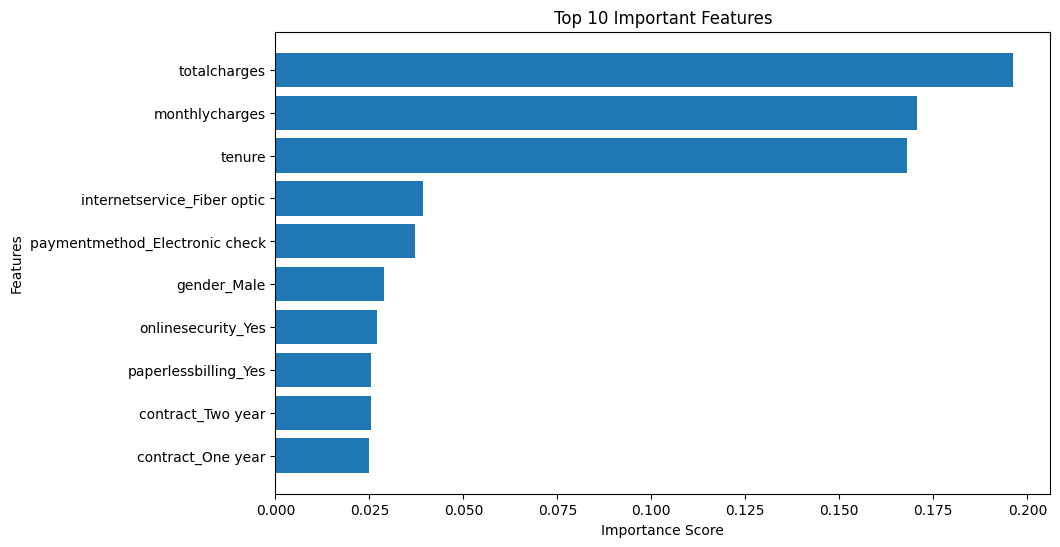

In [73]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Top 10 Important Features')
plt.gca().invert_yaxis()
plt.show()

## 📝 Step 18: Feature Importance Interpretation

### Key Findings

The most influential features contribute significantly to predicting customer churn.

Typical high-impact factors include:

- Contract Type
- Monthly Charges
- Tenure
- Internet Service Type
- Payment Method

### Business Impact

Customers with short tenure, high monthly charges, and month-to-month contracts are more likely to churn.

These customer segments should be prioritized for retention campaigns.

# 🎯 Final Project Conclusion

## Project Objective

The objective of this project was to analyze customer churn behavior and build predictive models to identify customers at risk of leaving.

## Work Completed

- Data Cleaning and Preprocessing
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Logistic Regression Model
- Random Forest Model
- Model Evaluation and Comparison
- Feature Importance Analysis

## Key Insights

- Month-to-month contract customers showed the highest churn rate.
- Fiber optic customers exhibited higher churn compared to other internet service types.
- Customers with higher monthly charges were more likely to churn.
- Tenure was a strong indicator of customer retention.

## Best Model

Random Forest provided better predictive performance compared to Logistic Regression and was selected as the final model.

## Business Recommendation

To reduce churn, the company should:

1. Encourage long-term contracts.
2. Improve customer experience for fiber optic users.
3. Focus retention efforts on new customers.
4. Offer incentives to high-risk customer segments.

## Conclusion

Machine Learning can effectively identify customers at risk of churn, enabling proactive retention strategies and improving overall customer lifetime value.

## 💾 Step 20: Save the Final Model

The trained Random Forest model is saved for future predictions and deployment.

In [74]:
import joblib

joblib.dump(rf_model, "../models/churn_rf_model.pkl")

['../models/churn_rf_model.pkl']

# 📄 Project Summary

This project focused on predicting customer churn using machine learning techniques.

## Project Workflow

1. Data Collection
2. Data Cleaning
3. Exploratory Data Analysis
4. Feature Engineering
5. Model Building
6. Model Evaluation
7. Feature Importance Analysis
8. Model Saving

## Models Used

- Logistic Regression
- Random Forest Classifier

## Final Outcome

The Random Forest model was selected as the final model due to its superior predictive performance.

The model can be used to identify customers at high risk of churn and support customer retention initiatives.

# ✅ Notebook Completion

This notebook successfully completed the machine learning phase of the Customer Churn Prediction project.

### Deliverables

- Trained Machine Learning Models
- Performance Evaluation
- Feature Importance Analysis
- Saved Prediction Model

The project is now ready for deployment, dashboard integration, or further business analysis.